# Analysis: Model Performance

Here we focus on capturing differences in model performance.

**Performance score** is calculated by:
- train models with inner and outer folds (10 outer folds, with 9 inner folds each)
- measure the cross-entropy, or Negative Log Likelihood (NLL), of next-action predictions in train, val (inner) and eval (outer) datasets.
- for each subject, each outer fold, select the inner fold with lowest NLL across train and inner validation datasets.
- for each subject, we take the mean across outer folds.
- Statistics are done at subject-level: for each subject, we therefore take the mean across outer folds for a subject-level score.


**Architectures** we have trained models which differ in:
- gating mechanisms ['GRU','lightGRU','monoGRU','vanilla']
- dimensionality [1, 2 or 3 hidden units]
- activation function ['relu', 'tanh']
- input encodings ['unipolar','onehot','encoder']
- decoder bias [with or without]

In [3]:
## setup ##
import os
os.chdir('/ceph/behrens/wsilver/reversal/code/')

from NM_TinyRNN.code.measures import analysis
from NM_TinyRNN.code.measures import mechanistic_variability as mech_var
#from NM_TinyRNN.code.measures import reversal_metrics as revme
from NM_TinyRNN.code.measures import plotting_stats

from NM_TinyRNN.code.models import submit_jobs # this is the code used to train models!

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload

CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
#construct analysis_df and have a look at a subset of data!
info_df = submit_jobs.get_DA_info_df()
all_models_df = analysis.get_analysis_df(info_df, mode='all')

# Note: model_type2, train_CE, val_CE, and eval_CE_computed are now computed 
# automatically by get_analysis_df() and included in the dataframe

print("Available model types (model_type2):")
print(all_models_df.model_type2.unique())

print("\nAvailable columns:")
print([col for col in all_models_df.columns if 'CE' in col or 'type' in col])

all_models_df

Loaded analysis_df from cache: NM_TinyRNN/data/analysis/analysis_df.htsv
Available model types (model_type2):
['vanilla+BC' 'vanilla+BC-DB' 'vanilla' 'GRU+BC' 'GRU+BC-DB' 'GRU'
 'lightGRU+BC' 'monoGRU+BC' 'monoGRU+BC-DB' 'monoGRU_abs'
 'monoGRU_no_hidden+BC-DB' 'monoGRU_hidden_only+BC-DB']

Available columns:
['model_type', 'model_type2', 'eval_CE', 'best_val_CE', 'train_CE', 'val_CE', 'eval_CE_computed']


,Index,subject_id,outer_loop_n,model_type,hidden_size,nonlinearity,constraint,decoder_bias,input_encoding,input_forced_choice,...,training_losses_path,trials_data_path,eval_CE,best_val_CE,weight_seed,sparsity_lambda,energy_lambda,train_CE,val_CE,eval_CE_computed
0,0,WS20,1,vanilla,1,relu,energy,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,0.652491,0.619712,4,0.00100,0.100,0.631331,0.641496,0.659734
1,0,WS20,1,vanilla,1,relu,energy,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,0.677118,0.622575,1,0.00100,0.100,0.631843,0.641517,0.670352
2,0,WS20,1,vanilla,1,relu,energy,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,0.653895,0.584325,4,0.00010,0.100,0.629327,0.622067,0.657516
3,0,WS20,1,vanilla,1,relu,energy,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,0.647392,0.571514,6,0.00100,0.001,0.624796,0.610521,0.652524
4,0,WS20,1,vanilla,1,relu,energy,True,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,NM_TinyRNN/data/rnns/nested_DA_128/WS20/vanill...,0.659813,0.558551,4,0.00010,0.100,0.627605,0.608877,0.658101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39865,4439,WS09,10,monoGRU_hidden_only,2,relu,energy,False,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/monoGR...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/monoGR...,0.598380,0.634917,3,0.00001,0.010,0.642782,0.645163,0.633725
39866,4439,WS09,10,monoGRU_hidden_only,2,relu,energy,False,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/monoGR...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/monoGR...,0.602608,0.551293,1,0.00100,0.001,0.650161,0.609517,0.637585
39867,4439,WS09,10,monoGRU_hidden_only,2,relu,energy,False,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/monoGR...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/monoGR...,0.599544,0.611177,1,0.00001,0.001,0.646315,0.638118,0.633636
39868,4439,WS09,10,monoGRU_hidden_only,2,relu,energy,False,unipolar,True,...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/monoGR...,NM_TinyRNN/data/rnns/nested_DA_128/WS09/monoGR...,0.597339,0.565021,1,0.00010,0.001,0.649331,0.615989,0.635307


# Main

## Ji-an style plot: comparing 1 and 2 unit models across architectures.


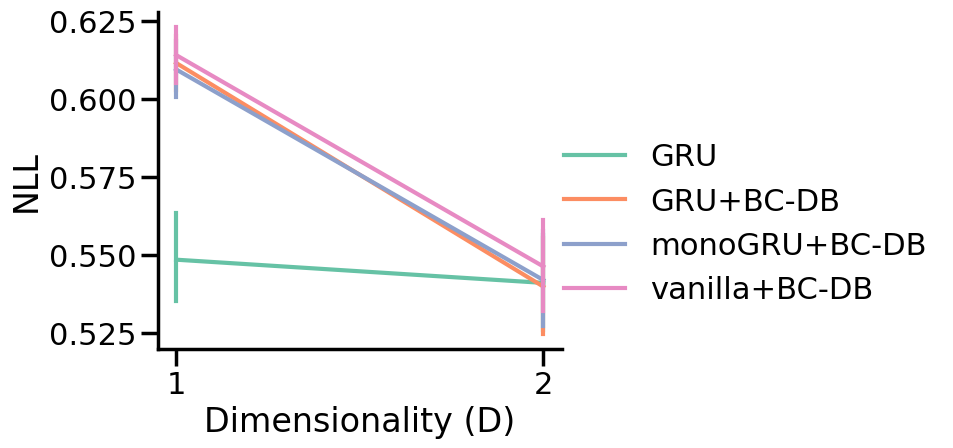

In [92]:

def select_best_outer(analysis_df):
    # --- SELECT MODEL WITH HIGHEST (val_CE + train_CE) ACROSS INNER FOLDS ---
    group_cols = ['model_type2', 'hidden_size', 'subject_id', 'outer_loop_n']
    # 3. Find indices corresponding to max total_CE across inner_fold_idx
    min_idx = analysis_df.groupby(group_cols)['val_CE'].idxmin()
    
    # 4. Filter DataFrame down to the selected inner fold runs
    select_models = analysis_df.loc[min_idx].drop(columns=['val_CE'])
    return select_models


sns.set_context('poster')
model_list = ["GRU", "GRU+BC-DB","monoGRU+BC-DB","vanilla+BC-DB"]
unipolar_models = all_models_df.query('input_encoding=="unipolar"')
unipolar_models = unipolar_models[unipolar_models.model_type2.isin(model_list)]
unipolar_models = select_best_outer(unipolar_models)

g = sns.relplot(unipolar_models, x='hidden_size',y='eval_CE', kind = 'line', 
                hue= 'model_type2', palette = "Set2",
                err_style = 'bars',
                col_order = ['tanh','relu'],
                hue_order = model_list,
                aspect = 1.4)
g.legend.set(title = '')
g.set(ylabel = 'NLL', xlabel = 'Dimensionality (D)', xticks = [1,2])

## Unipolar models: are 1-unit models better than 2-unit models?

We focus on unipolar encodings, as these were adopted by Ji-an et al., and seem the 'most' biological when considering the temporal separation of different events.



PAIRED COMPARISON DIAGNOSTIC RUN REPORT
        group            test_used                           reason  outliers_present  p_corrected
          GRU Wilcoxon Signed-Rank                Outliers detected              True     0.002441
       GRU+BC        Paired t-test Normal distribution, no outliers             False     0.000081
  lightGRU+BC        Paired t-test Normal distribution, no outliers             False     0.000073
   monoGRU+BC        Paired t-test Normal distribution, no outliers             False     0.002004
monoGRU+BC-DB        Paired t-test Normal distribution, no outliers             False     0.000008
vanilla+BC-DB        Paired t-test Normal distribution, no outliers             False     0.000005



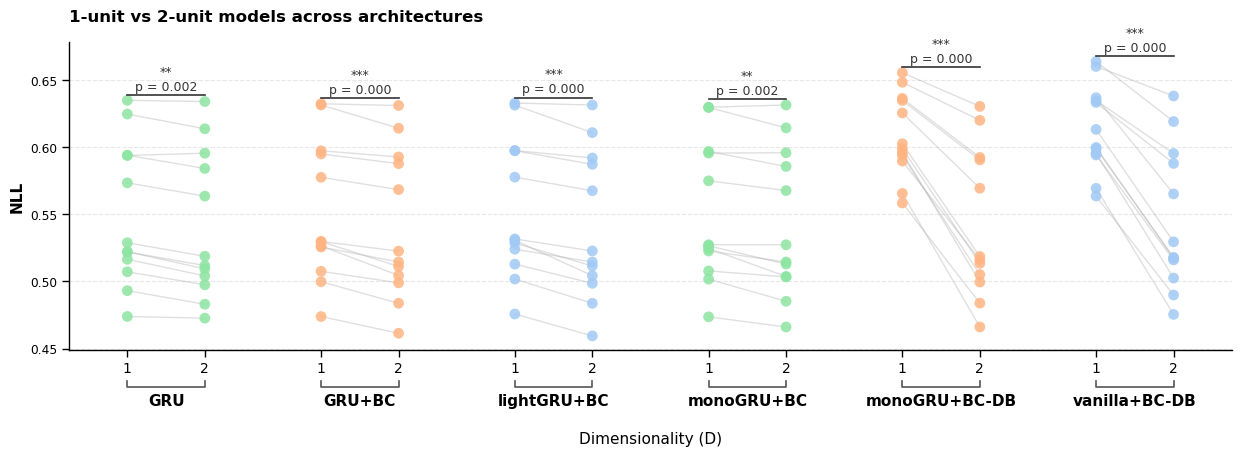

In [15]:
## Are 1D models better than 2D models?
reload(analysis)
reload(plotting_stats)
#we compare vanilla and GRU with different input encodings
sns.set_context('paper')
model_list = ['GRU','GRU+BC','lightGRU+BC','monoGRU+BC','monoGRU+BC-DB','vanilla+BC-DB']
fig, ax = plt.subplots(figsize = (15,4))
select_models = all_models_df[all_models_df.model_type2.isin(model_list)]
select_models = select_models.query('input_encoding == "unipolar"')
select_models = analysis.select_best_outer(select_models)

palette = sns.color_palette('pastel')[0:3]
palette = (palette[2], palette[1],palette[0])
axis, ttest = plotting_stats.plot_paired_comparison(select_models,
                                                y='eval_CE',
                                                x='hidden_size',
                                                within_variable='model_type2', 
                                                paired_across='subject_id',
                                                mean_across='outer_loop_n',
                                                hue_order = model_list, 
                                                colors = palette, 
                                                ax = ax,
                                                title = "1-unit vs 2-unit models across architectures")

axis.set(ylabel = 'NLL', xlabel = 'Dimensionality (D)')
plt.show()
    

In [ ]:
## 

## Unipolar 2 unit models: difference across architectures

We want to compare model performance of 2-unit models across the different architectures. Here we preform an ANOVA.




UnboundLocalError: cannot access local variable 'select_models' where it is not associated with a value

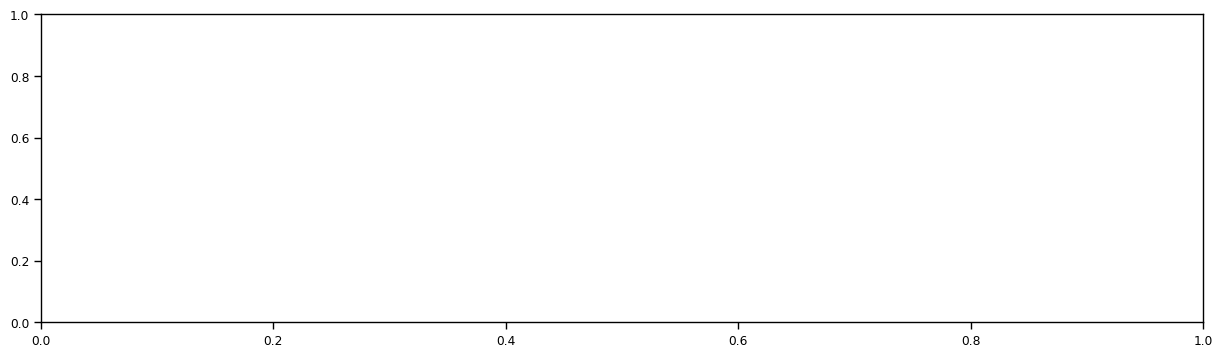

In [93]:
## Are 1D models better than 2D models?
reload(analysis)
reload(plotting_stats)
#we compare vanilla and GRU with different input encodings
sns.set_context('paper')
model_list = ['GRU','GRU+BC','lightGRU+BC','monoGRU+BC','monoGRU+BC-DB','vanilla+BC-DB']
fig, ax = plt.subplots(figsize = (15,4))
select_models = all_models_df[all_models_df.model_type2.isin(model_list)]
select_models = select_models.query('input_encoding == "unipolar"')
select_models = select_models.query('hidden_size==2')
select_models = analysis.select_best_outer(select_models)

palette = sns.color_palette('pastel')[0:3]
palette = (palette[2], palette[1],palette[0])
axis, ttest = plotting_stats.plot_paired_comparison(select_models,
                                                y='eval_CE',
                                                x='model_type2',
                                                within_variable='hidden_size', 
                                                paired_across='subject_id',
                                                mean_across='outer_loop_n',
                                                hue_order = model_list, 
                                                colors = palette, 
                                                ax = ax,
                                                title = "1-unit vs 2-unit models across architectures")

axis.set(ylabel = 'NLL', xlabel = 'Dimensionality (D)')
plt.show()
    

In [ ]:
## Are 1D models better than 2D models?
reload(analysis)
reload(plotting_stats)
#we compare vanilla and GRU with different input encodings
sns.set_context('paper')
model_list = ['GRU','GRU+BC','lightGRU+BC','monoGRU+BC','monoGRU+BC-DB','vanilla+BC-DB']
fig, ax = plt.subplots(figsize = (15,4))
select_models = all_models_df[all_models_df.model_type2.isin(model_list)]
select_models = select_models.query('input_encoding == "unipolar"')
select_models = analysis.select_best_outer(select_models)

palette = sns.color_palette('pastel')[0:3]
palette = (palette[2], palette[1],palette[0])
axis, ttest = plotting_stats.plot_paired_comparison(select_models,
                                                y='eval_CE',
                                                x='hidden_size',
                                                within_variable='model_type2', 
                                                paired_across='subject_id',
                                                mean_across='outer_loop_n',
                                                hue_order = model_list, 
                                                colors = palette, 
                                                ax = ax,
                                                title = "1-unit vs 2-unit models across architectures")

axis.set(ylabel = 'NLL', xlabel = 'Dimensionality (D)')
plt.show()
    

Index(['Index', 'subject_id', 'outer_loop_n', 'model_type', 'hidden_size',
       'nonlinearity', 'constraint', 'decoder_bias', 'input_encoding',
       'input_forced_choice', 'nm_size', 'nm_dim', 'nm_mode', 'model_id',
       'save_path', 'data_path', 'completed', 'model_type2', 'inner_loop_idx',
       'info_path', 'model_state_path', 'model_pickle_path',
       'training_losses_path', 'trials_data_path', 'eval_CE', 'best_val_CE',
       'weight_seed', 'sparsity_lambda', 'energy_lambda', 'train_CE', 'val_CE',
       'eval_CE_computed'],
      dtype='object')

/tmp/ipykernel_75884/1171313504.py:178: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_agg)



Outlier-fold exclusion summary (6 subject/model groups affected):
subject_id   model_type2  n_total  n_excluded      excluded_values  mean_before  mean_after
      WS16           GRU       10           1 [0.6499771475791931]     0.500087    0.483433
      WS16        GRU+BC       10           1 [0.6397716403007507]     0.499573    0.483995
      WS16   lightGRU+BC       10           1 [0.6406428813934326]     0.504205    0.489045
      WS16    monoGRU+BC       10           1 [0.6409196853637695]     0.503606    0.488349
      WS16 monoGRU+BC-DB       10           1 [0.6363013386726379]     0.505048    0.490464
      WS16 vanilla+BC-DB       10           1 [0.6491605043411255]     0.515924    0.501119

Subject x model matrix (12 subjects x 6 models):
model_type2       GRU    GRU+BC  lightGRU+BC  monoGRU+BC  monoGRU+BC-DB  \
subject_id                                                                
WS01         0.578571  0.582138     0.587024    0.585443       0.590313   
WS02         0

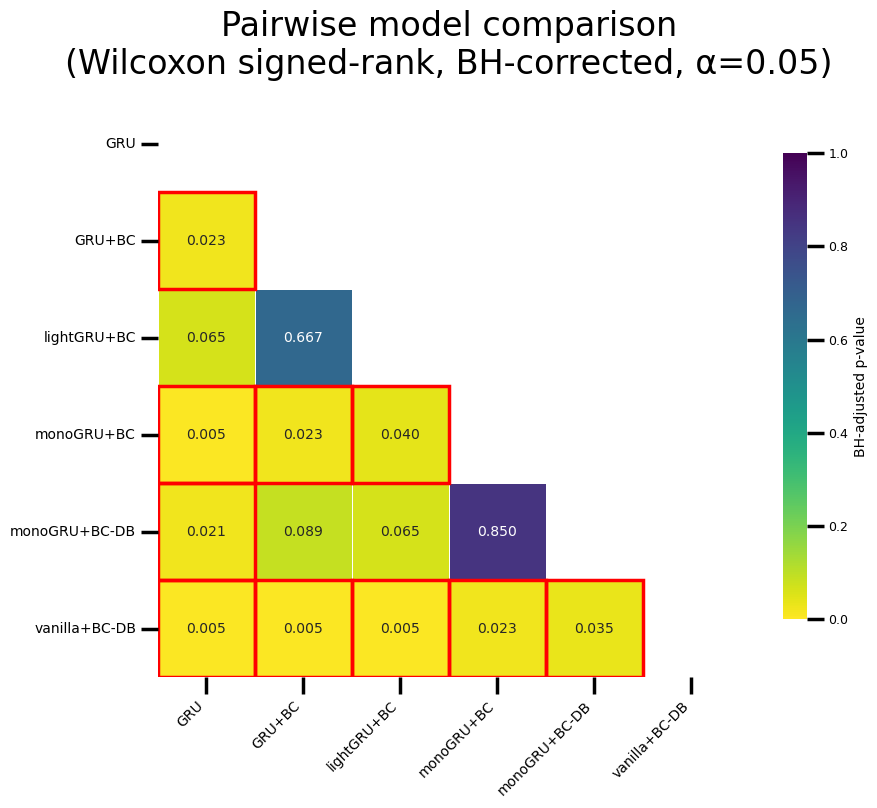

/tmp/ipykernel_75884/1171313504.py:178: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_agg)



Outlier-fold exclusion summary (6 subject/model groups affected):
subject_id   model_type2  n_total  n_excluded      excluded_values  mean_before  mean_after
      WS16           GRU       10           1 [0.6499771475791931]     0.500087    0.483433
      WS16        GRU+BC       10           1 [0.6397716403007507]     0.499573    0.483995
      WS16   lightGRU+BC       10           1 [0.6406428813934326]     0.504205    0.489045
      WS16    monoGRU+BC       10           1 [0.6409196853637695]     0.503606    0.488349
      WS16 monoGRU+BC-DB       10           1 [0.6363013386726379]     0.505048    0.490464
      WS16 vanilla+BC-DB       10           1 [0.6491605043411255]     0.515924    0.501119

9 / 15 pairwise comparisons flip significance depending on aggregator choice.
Disagreeing pairs:
      model_1       model_2  mean  median  mean_outliers_removed  agrees_across_all
          GRU        GRU+BC  True   False                   True              False
          GRU    monoGR

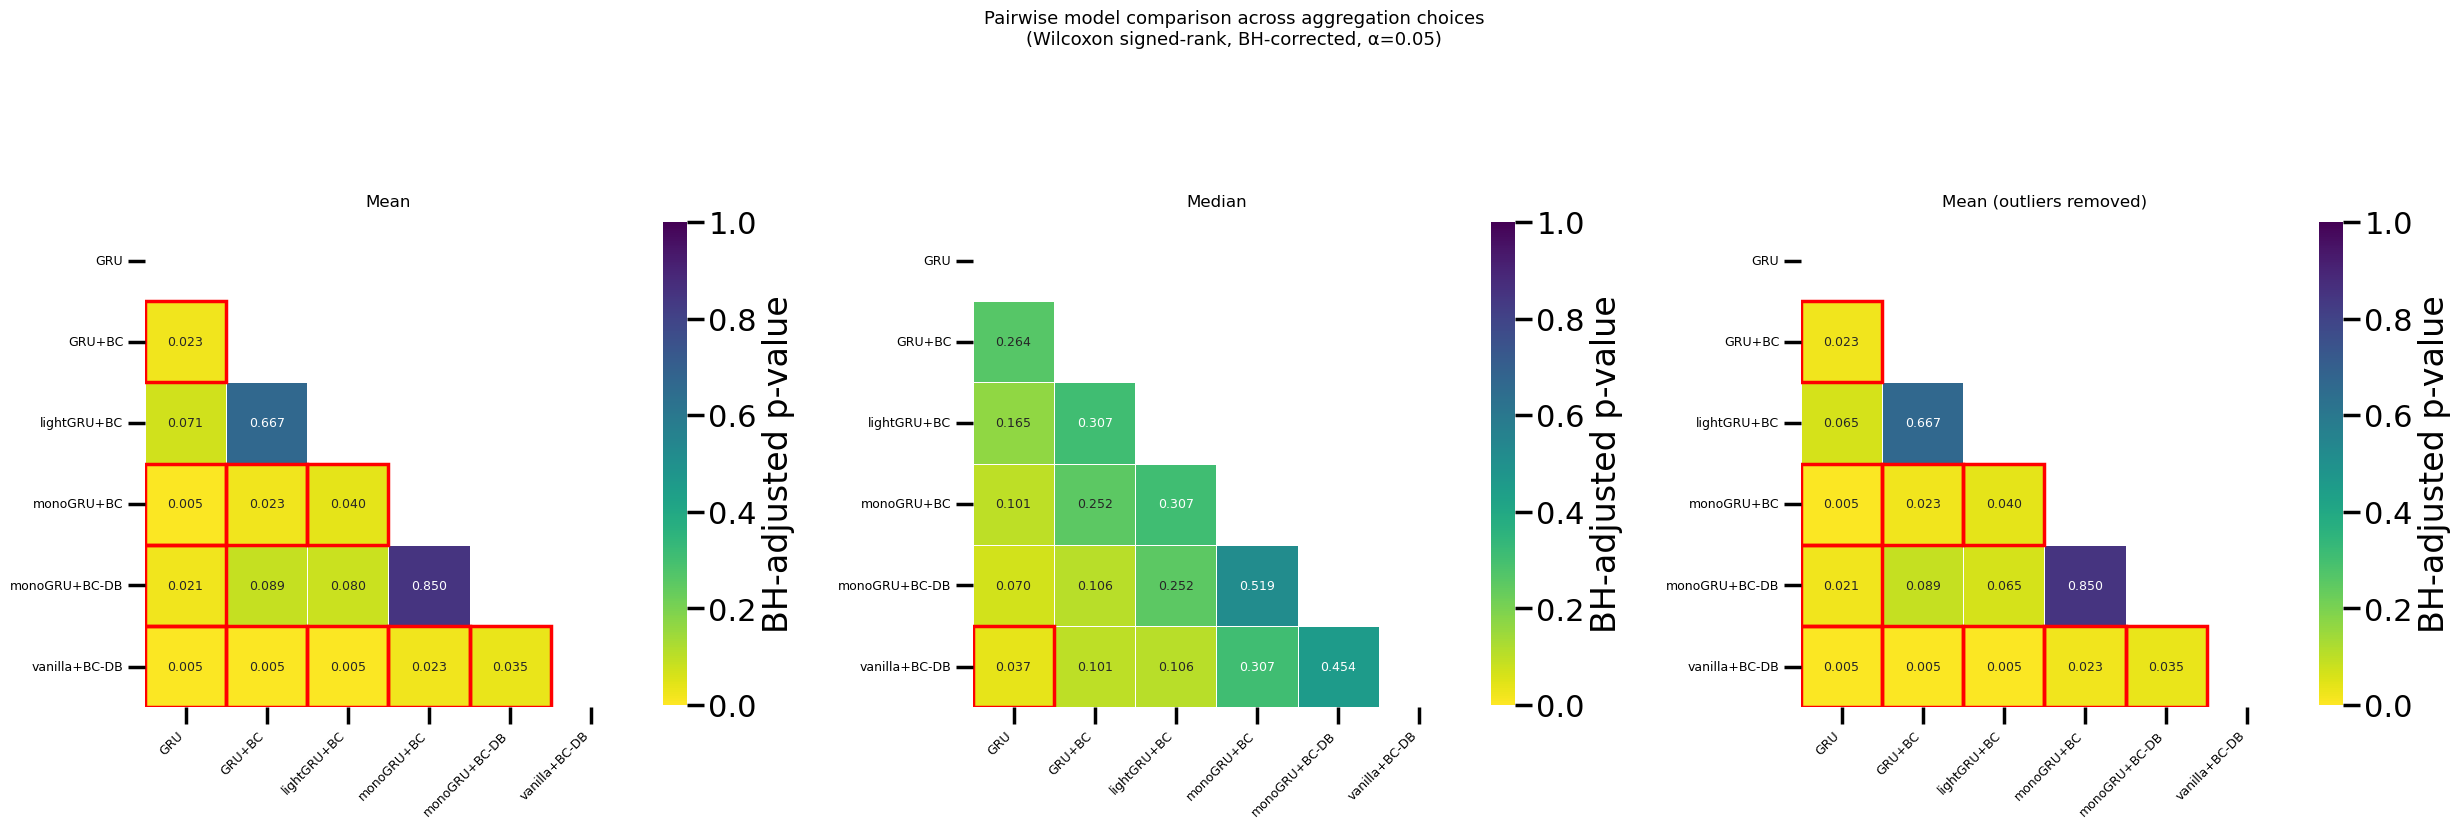

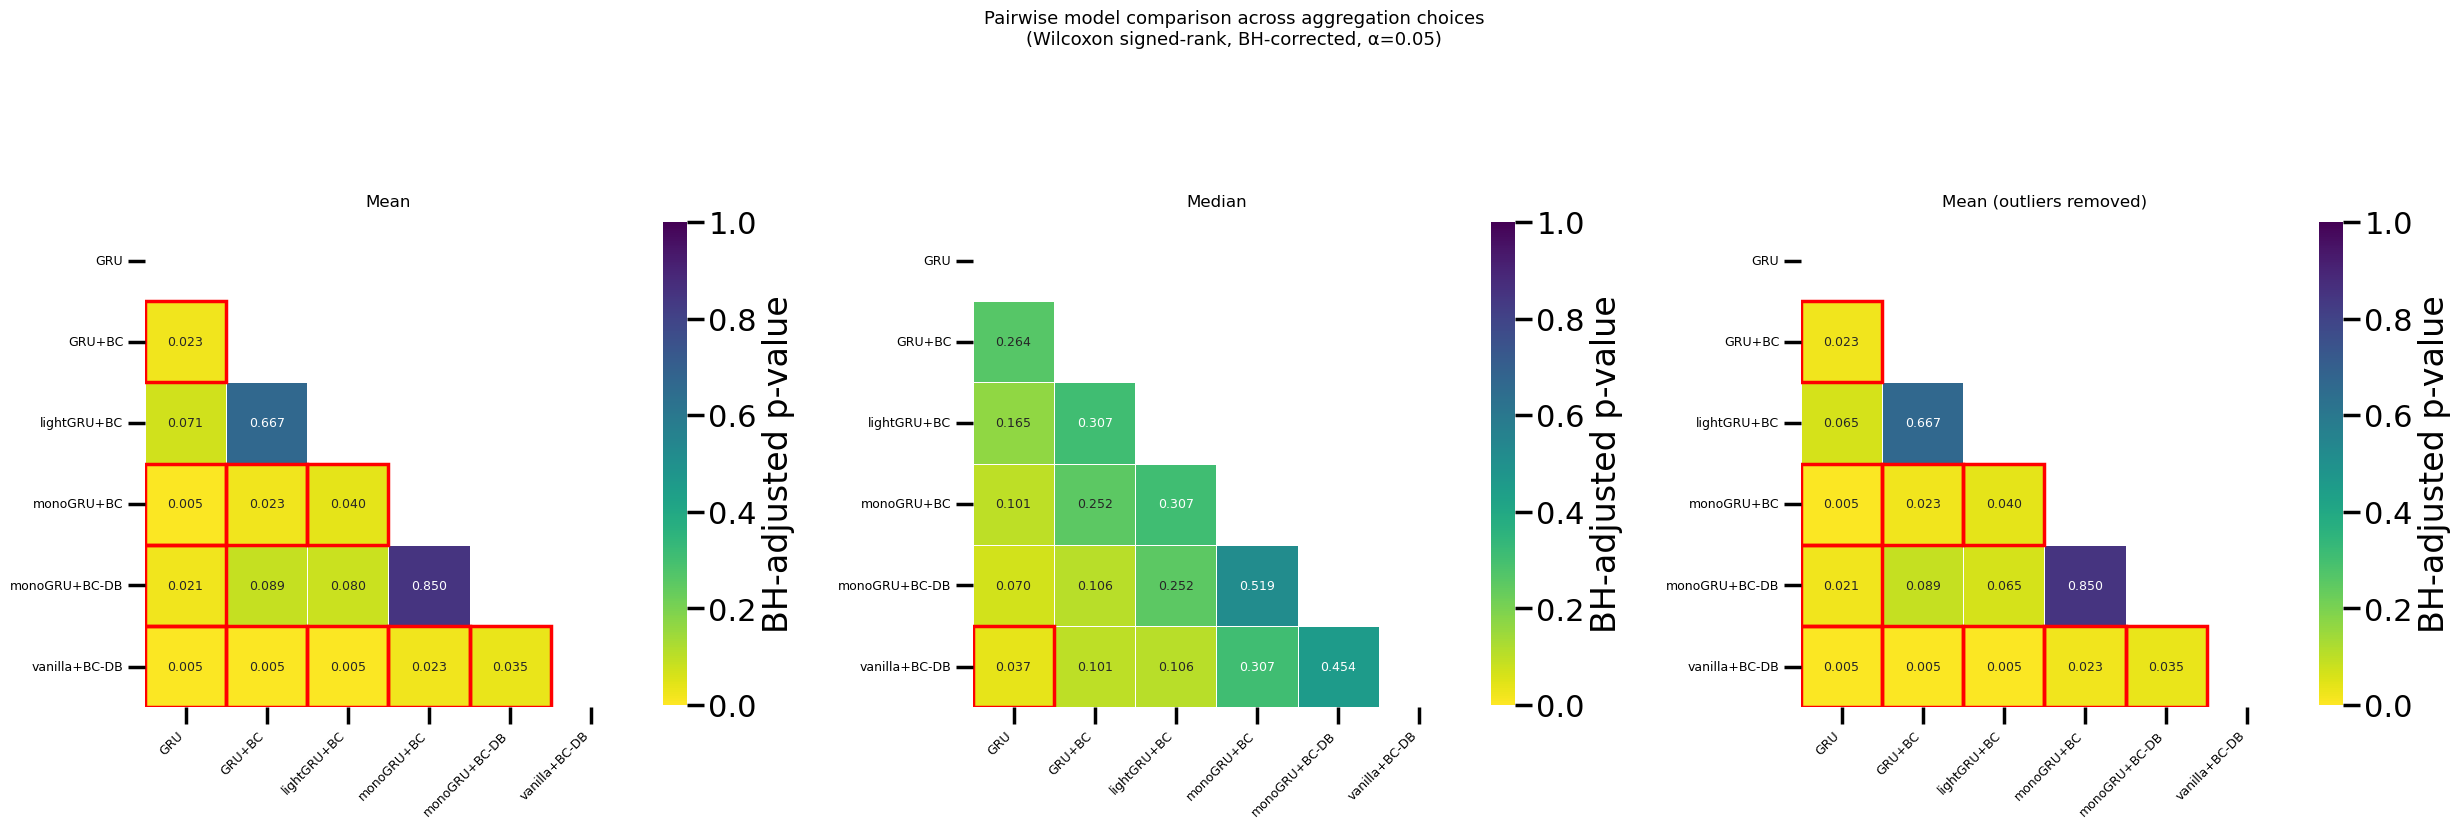

In [86]:
# are 2-unit GRU models better than 2-unit vanilla RNNS?
#Is there a difference for 2-unit relu models across architectures?
model_list = ['GRU','GRU+BC','lightGRU+BC','monoGRU+BC','monoGRU+BC-DB','vanilla+BC-DB']
sns.set_context('poster')
reload(plotting_stats)
select_models = all_models_df.query('hidden_size==2')
select_models = select_models[select_models.model_type2.isin(model_list)]
select_models = analysis.select_best_outer(select_models)

"""
Subject-level paired comparison of model performance (eval_CE) across model_type2.

Pipeline:
1. Average eval_CE per (subject_id, model_type2) across outer_loop_n.
2. Pivot to wide format: subjects x models.
3. Run pairwise Wilcoxon signed-rank tests for every model pair.
4. Apply Benjamini-Hochberg (FDR) correction across all pairwise p-values.
5. Visualize as a lower-triangular heatmap of adjusted p-values, with
   significant cells outlined.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from sklearn.mixture import GaussianMixture


MODEL_LIST = ['GRU', 'GRU+BC', 'lightGRU+BC', 'monoGRU+BC', 'monoGRU+BC-DB', 'vanilla+BC-DB']


def flag_outlier_folds_gmm(
    values: np.ndarray,
    min_n: int = 6,
    minority_weight_threshold: float = 0.3,
    bic_margin: float = 10.0,
    min_separation_sigma: float = 2.5,
    max_relative_std: float = 0.6,
    random_state: int = 0,
) -> np.ndarray:
    """
    Flag "failed run" outlier folds within a single subject/model group's
    outer-fold eval_CE values, using a gated 2-component GMM.

    eval_CE is a loss (lower = better), so a failed/divergent run shows up
    as an ABNORMALLY HIGH cluster of values, not a low one. This function
    only ever flags the higher-mean component, and only when all of the
    following hold — each guards against over-triggering, so that most
    well-behaved subject/model groups get zero exclusions:

    1. Bimodality is strongly supported: a 2-component GMM must beat a
       1-component GMM by more than `bic_margin` in BIC. This is a high
       bar on purpose — ordinary noisy-but-unimodal data should never
       trigger a split.
    2. The high cluster is a clear minority (< `minority_weight_threshold`
       of points) — a near-even split is treated as a genuine difficulty
       effect, not a handful of failed runs, and is left untouched.
    3. The high cluster is well SEPARATED from the main cluster, by at
       least `min_separation_sigma` pooled standard deviations — guards
       against flagging a mild, continuous tail as a distinct cluster.
    4. The high cluster is DENSE (tight) relative to the main cluster:
       its std must be no more than `max_relative_std` times the main
       cluster's std. Failed runs should look like a tight abnormal
       bump, not a diffuse spread of high-ish values.

    Returns a boolean array (True = flagged as outlier) aligned with `values`.
    """
    values = np.asarray(values, dtype=float)
    n = len(values)
    flags = np.zeros(n, dtype=bool)

    if n < min_n:
        # not enough points to fit a reliable 2-component model
        return flags

    X = values.reshape(-1, 1)

    gmm1 = GaussianMixture(n_components=1, n_init=5, random_state=random_state).fit(X)
    gmm2 = GaussianMixture(n_components=2, n_init=5, random_state=random_state).fit(X)

    bic1, bic2 = gmm1.bic(X), gmm2.bic(X)

    # (1) require strong evidence of bimodality
    if bic1 - bic2 < bic_margin:
        return flags

    labels = gmm2.predict(X)
    means = gmm2.means_.ravel()
    stds = np.sqrt(gmm2.covariances_.ravel())
    weights = gmm2.weights_.ravel()

    high_idx = int(np.argmax(means))
    low_idx = 1 - high_idx

    # (2) high cluster must be a clear minority
    if weights[high_idx] >= minority_weight_threshold:
        return flags

    # (3) require clear separation, in units of pooled std
    pooled_std = np.sqrt(weights[low_idx] * stds[low_idx] ** 2 + weights[high_idx] * stds[high_idx] ** 2)
    if pooled_std <= 1e-12:
        return flags
    separation = (means[high_idx] - means[low_idx]) / pooled_std
    if separation < min_separation_sigma:
        return flags

    # (4) require the high cluster to be dense/tight, not a diffuse tail
    if stds[low_idx] <= 1e-12 or stds[high_idx] > max_relative_std * stds[low_idx]:
        return flags

    flags = labels == high_idx
    return flags


def prepare_subject_means(
    df: pd.DataFrame,
    model_list: list,
    model_col: str = 'model_type2',
    subject_col: str = 'subject_id',
    outer_loop_col: str = 'outer_loop_n',
    value_col: str = 'eval_CE',
    aggregator: str = 'mean',
    remove_outliers: bool = False,
    outlier_kwargs: dict = None,
) -> pd.DataFrame:
    """
    Aggregate value_col over outer_loop_col per (subject, model), then pivot
    to a wide subject x model dataframe.

    aggregator: 'mean' or 'median'.
    remove_outliers: if True, applies flag_outlier_folds_gmm() within each
        (subject, model) group before aggregating, and drops flagged folds.
        Only meaningful with aggregator='mean' (median is already robust to
        the outliers this targets).
    outlier_kwargs: passed through to flag_outlier_folds_gmm.
    """
    assert aggregator in ('mean', 'median')
    outlier_kwargs = outlier_kwargs or {}

    df_filt = df[df[model_col].isin(model_list)].copy()

    # sanity check: warn about subjects/models missing outer_loop repeats
    n_loops = df_filt.groupby([subject_col, model_col])[outer_loop_col].nunique()
    if n_loops.nunique() > 1:
        print("Note: number of outer_loop_n repeats is not uniform across "
              "subject/model combinations:")
        print(n_loops.unstack())

    if remove_outliers:
        exclusion_log = []

        def _agg(group):
            # group.name is the (subject, model) key tuple since we grouped on both
            subj_val, model_val = group.name
            vals = group[value_col].values
            flags = flag_outlier_folds_gmm(vals, **outlier_kwargs)
            n_excluded = flags.sum()
            if n_excluded > 0:
                exclusion_log.append({
                    subject_col: subj_val,
                    model_col: model_val,
                    'n_total': len(vals),
                    'n_excluded': int(n_excluded),
                    'excluded_values': vals[flags].tolist(),
                    'mean_before': np.mean(vals),
                    'mean_after': np.mean(vals[~flags]) if n_excluded < len(vals) else np.nan,
                })
            kept = vals[~flags]
            if len(kept) == 0:
                return np.nan
            return np.mean(kept) if aggregator == 'mean' else np.median(kept)

        subj_agg = (
            df_filt.groupby([subject_col, model_col])
            .apply(_agg)
            .reset_index(name=value_col)
        )

        if exclusion_log:
            log_df = pd.DataFrame(exclusion_log).sort_values('n_excluded', ascending=False)
            print(f"\nOutlier-fold exclusion summary ({len(log_df)} subject/model groups affected):")
            print(log_df.to_string(index=False))
        else:
            print("\nNo groups showed evidence of bimodal outlier folds (no exclusions made).")
    else:
        agg_func = 'mean' if aggregator == 'mean' else 'median'
        subj_agg = (
            df_filt.groupby([subject_col, model_col])[value_col]
            .agg(agg_func)
            .reset_index()
        )

    wide = subj_agg.pivot(index=subject_col, columns=model_col, values=value_col)
    wide = wide[model_list]  # enforce consistent column order
    return wide


def plot_outlier_diagnostics(
    df: pd.DataFrame,
    subject_id,
    model_list: list,
    model_col: str = 'model_type2',
    subject_col: str = 'subject_id',
    outer_loop_col: str = 'outer_loop_n',
    value_col: str = 'eval_CE',
    outlier_kwargs: dict = None,
):
    """
    Diagnostic plot for one subject: shows outer-fold eval_CE per model,
    with points flagged by flag_outlier_folds_gmm() marked in red.
    Use this to sanity-check the exclusion rule before trusting it.
    """
    outlier_kwargs = outlier_kwargs or {}
    sub = df[(df[subject_col] == subject_id) & (df[model_col].isin(model_list))]

    fig, axes = plt.subplots(1, len(model_list), figsize=(3 * len(model_list), 3.5), sharey=True)
    if len(model_list) == 1:
        axes = [axes]

    for ax, model in zip(axes, model_list):
        group = sub[sub[model_col] == model].sort_values(outer_loop_col)
        vals = group[value_col].values
        flags = flag_outlier_folds_gmm(vals, **outlier_kwargs)

        x = np.arange(len(vals))
        ax.scatter(x[~flags], vals[~flags], color='tab:blue', label='kept', zorder=3)
        ax.scatter(x[flags], vals[flags], color='tab:red', label='excluded', zorder=3)
        ax.axhline(np.mean(vals), color='gray', ls='--', lw=1, label='mean (all)')
        if flags.any():
            ax.axhline(np.mean(vals[~flags]), color='black', ls='--', lw=1, label='mean (kept)')
        ax.set_title(model, fontsize=10)
        ax.set_xlabel(outer_loop_col)

    axes[0].set_ylabel(value_col)
    axes[0].legend(fontsize=7, loc='best')
    fig.suptitle(f'Outlier-fold diagnostic: subject {subject_id}')
    fig.tight_layout()
    return fig


def pairwise_wilcoxon(wide_df: pd.DataFrame, model_list: list, alpha: float = 0.05) -> pd.DataFrame:
    """
    Run Wilcoxon signed-rank test for every pair of models (columns),
    using only subjects with data for both models (paired, listwise deletion
    per pair). Applies BH (FDR) correction across all pairs.
    """
    results = []
    for m1, m2 in combinations(model_list, 2):
        paired = wide_df[[m1, m2]].dropna()
        n = len(paired)

        if n == 0:
            results.append({
                'model_1': m1, 'model_2': m2, 'n_subjects': 0,
                'statistic': np.nan, 'p_value': np.nan,
                'median_diff': np.nan,
            })
            continue

        x, y = paired[m1].values, paired[m2].values
        diffs = x - y

        if np.all(diffs == 0):
            # wilcoxon errors out if all differences are zero
            stat, p = np.nan, 1.0
        else:
            stat, p = wilcoxon(x, y, zero_method='wilcox', alternative='two-sided')

        results.append({
            'model_1': m1,
            'model_2': m2,
            'n_subjects': n,
            'statistic': stat,
            'p_value': p,
            'median_diff': np.median(diffs),  # median(m1 - m2)
        })

    results_df = pd.DataFrame(results)

    # BH correction, ignoring any NaN p-values (e.g. from empty pairs)
    valid = results_df['p_value'].notna()
    p_adj = np.full(len(results_df), np.nan)
    reject = np.full(len(results_df), False)
    if valid.sum() > 0:
        reject_valid, p_adj_valid, _, _ = multipletests(
            results_df.loc[valid, 'p_value'], alpha=alpha, method='fdr_bh'
        )
        p_adj[valid.values] = p_adj_valid
        reject[valid.values] = reject_valid

    results_df['p_adj'] = p_adj
    results_df['significant'] = reject
    return results_df


def build_symmetric_matrix(results_df: pd.DataFrame, model_list: list, value_col: str) -> pd.DataFrame:
    mat = pd.DataFrame(np.nan, index=model_list, columns=model_list)
    for _, row in results_df.iterrows():
        mat.loc[row['model_1'], row['model_2']] = row[value_col]
        mat.loc[row['model_2'], row['model_1']] = row[value_col]
    return mat


def plot_comparison_matrix(
    results_df: pd.DataFrame,
    model_list: list,
    alpha: float = 0.05,
    save_path: str = None,
):
    p_mat = build_symmetric_matrix(results_df, model_list, 'p_adj')
    n = len(model_list)

    # only show the lower triangle (each pair shown once)
    mask = np.triu(np.ones_like(p_mat, dtype=bool))

    # scale figure size with number of models so labels/cells have room
    fig, ax = plt.subplots(figsize=(1.3 * n + 3, 1.1 * n + 2))

    sns.heatmap(
        p_mat, mask=mask, annot=True, fmt='.3f', cmap='viridis_r',
        vmin=0, vmax=1,
        annot_kws={'size': 10},
        cbar_kws={'label': 'BH-adjusted p-value', 'shrink': 0.8},
        linewidths=0.5, linecolor='white', ax=ax, square=True,
    )

    # outline significant cells in red
    for i in range(n):
        for j in range(n):
            if i > j:
                val = p_mat.iloc[i, j]
                if pd.notna(val) and val < alpha:
                    ax.add_patch(plt.Rectangle(
                        (j, i), 1, 1, fill=False, edgecolor='red', lw=2.5
                    ))

    ax.set_title(
        f'Pairwise model comparison\n(Wilcoxon signed-rank, BH-corrected, '
        f'\u03b1={alpha})',
        pad=15,
    )
    ax.set_xlabel('')
    ax.set_ylabel('')

    # keep row labels horizontal and readable; rotate column labels
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)

    # colorbar label font size (grab the last axes, which is the colorbar)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=9)
    cbar.ax.set_ylabel('BH-adjusted p-value', fontsize=10)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    return fig


def run_all_variants(df: pd.DataFrame, model_list: list, alpha: float = 0.05) -> dict:
    """
    Runs the full pipeline under three aggregation choices and returns a
    dict of {variant_name: pairwise_wilcoxon results_df}:
      - 'mean': plain mean across outer folds
      - 'median': plain median across outer folds
      - 'mean_outliers_removed': mean after GMM-based exclusion of
         abnormally high, tight, minority-cluster outlier folds
    """
    variants_wide = {
        'mean': prepare_subject_means(df, model_list, aggregator='mean'),
        'median': prepare_subject_means(df, model_list, aggregator='median'),
        'mean_outliers_removed': prepare_subject_means(
            df, model_list, aggregator='mean', remove_outliers=True
        ),
    }
    return {name: pairwise_wilcoxon(wide, model_list, alpha=alpha)
            for name, wide in variants_wide.items()}


def compare_aggregators(results_by_variant: dict) -> pd.DataFrame:
    """
    Takes the dict returned by run_all_variants() and reports whether the
    pattern of significant pairs agrees across variants. Use this as the
    robustness check: if conclusions are stable, the choice of aggregator
    doesn't matter for your story; if they diverge, that's worth reporting
    explicitly rather than silently picking the aggregator you prefer.
    """
    summary = None
    for name, res in results_by_variant.items():
        r = res[['model_1', 'model_2', 'significant']].rename(columns={'significant': name})
        summary = r if summary is None else summary.merge(r, on=['model_1', 'model_2'])

    variant_names = list(results_by_variant.keys())
    summary['agrees_across_all'] = summary[variant_names].nunique(axis=1) == 1

    n_disagree = (~summary['agrees_across_all']).sum()
    print(f"\n{n_disagree} / {len(summary)} pairwise comparisons flip significance "
          f"depending on aggregator choice.")
    if n_disagree > 0:
        print("Disagreeing pairs:")
        print(summary[~summary['agrees_across_all']].to_string(index=False))

    return summary


def plot_all_aggregator_matrices(
    results_by_variant: dict,
    model_list: list,
    alpha: float = 0.05,
    titles: dict = None,
    save_path: str = None,
):
    """
    Plots the lower-triangular BH-adjusted p-value heatmap for each
    aggregator variant side by side, on a shared color scale, so you can
    visually compare how the choice of aggregator changes the result.
    """
    titles = titles or {
        'mean': 'Mean',
        'median': 'Median',
        'mean_outliers_removed': 'Mean (outliers removed)',
    }
    n_models = len(model_list)
    n_variants = len(results_by_variant)
    mask = np.triu(np.ones((n_models, n_models), dtype=bool))

    fig, axes = plt.subplots(
        1, n_variants,
        figsize=((1.15 * n_models + 1.5) * n_variants, 1.05 * n_models + 2),
    )
    if n_variants == 1:
        axes = [axes]

    for ax, (name, results_df) in zip(axes, results_by_variant.items()):
        p_mat = build_symmetric_matrix(results_df, model_list, 'p_adj')

        sns.heatmap(
            p_mat, mask=mask, annot=True, fmt='.3f', cmap='viridis_r',
            vmin=0, vmax=1, annot_kws={'size': 9},
            cbar_kws={'label': 'BH-adjusted p-value', 'shrink': 0.8},
            linewidths=0.5, linecolor='white', ax=ax, square=True,
        )

        for i in range(n_models):
            for j in range(n_models):
                if i > j:
                    val = p_mat.iloc[i, j]
                    if pd.notna(val) and val < alpha:
                        ax.add_patch(plt.Rectangle(
                            (j, i), 1, 1, fill=False, edgecolor='red', lw=2.5
                        ))

        ax.set_title(titles.get(name, name), fontsize=12, pad=10)
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

    fig.suptitle(
        f'Pairwise model comparison across aggregation choices\n'
        f'(Wilcoxon signed-rank, BH-corrected, \u03b1={alpha})',
        fontsize=13,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.93])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    return fig


# --- 1. Primary analysis: mean with GMM-based outlier-fold exclusion ---
wide = prepare_subject_means(
    select_models, MODEL_LIST, aggregator='mean', remove_outliers=True
)
print(f"\nSubject x model matrix ({wide.shape[0]} subjects x {wide.shape[1]} models):")
print(wide)

results_df = pairwise_wilcoxon(wide, MODEL_LIST)
print("\nPairwise Wilcoxon results (sorted by adjusted p-value):")
print(results_df.sort_values('p_adj').to_string(index=False))

plot_comparison_matrix(results_df, MODEL_LIST, alpha=0.05,
                        save_path='model_comparison_matrix.png')

# --- 2. Optional: sanity-check the exclusion rule for one subject ---
# plot_outlier_diagnostics(df, subject_id='WS08', model_list=MODEL_LIST)

# --- 3. Robustness check: does the choice of aggregator matter? ---
results_by_variant = run_all_variants(select_models, MODEL_LIST, alpha=0.05)
sensitivity_summary = compare_aggregators(results_by_variant)
plot_all_aggregator_matrices(results_by_variant, MODEL_LIST, alpha=0.05,
                                save_path='model_comparison_all_variants.png')




# Supplementary

Here we include further explorations which supplement the primary narrative of the paper

## per-subject inner x outer loop losses

We are interested in knowing whether there's a trend towards some folds having worse fits.

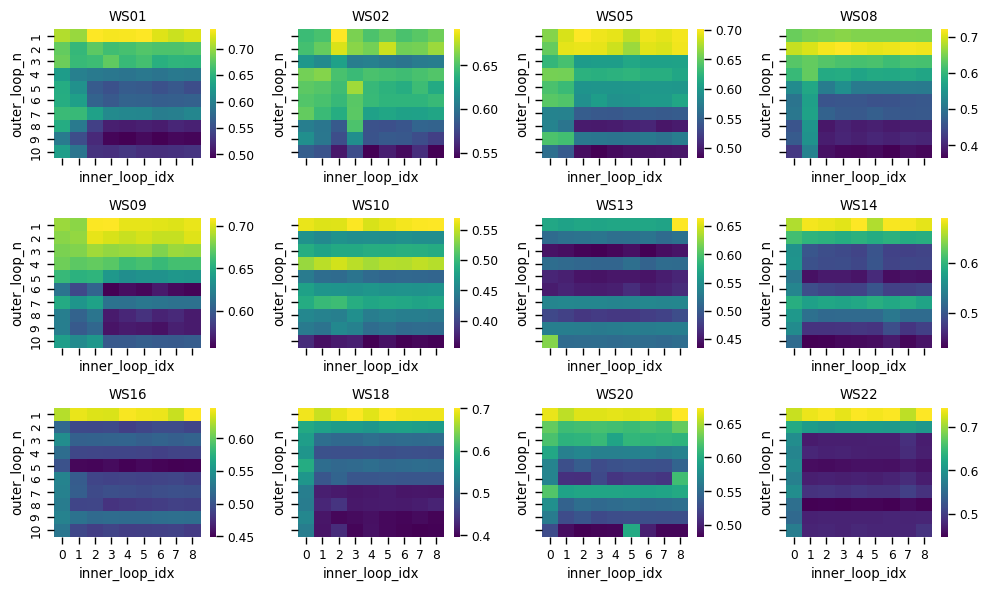

In [74]:
# for example, let's select a particular model
sns.set_context('paper')
model_id = '2_unit_monoGRU_relu_unipolar_forced_ndb' #minimal variation monoGRU
model_df = all_models_df.query(f'model_id=="{model_id}"')
fig, ax = plt.subplots(3,4, figsize = (10,6), sharex = True, sharey=True)
flat_ax = ax.flatten()
for i, each_subject in enumerate(model_df.subject_id.unique()):
    subject_df = model_df.query(f'subject_id=="{each_subject}"')
    pivot_df = subject_df.pivot(index="outer_loop_n",columns = "inner_loop_idx",values="eval_CE")
    sns.heatmap(pivot_df, ax=flat_ax[i], cmap='viridis')
    flat_ax[i].set_title(f'{each_subject}')
    
fig.tight_layout()

## Exploring the role of input encodings

